# PPO Demo on the Crawler

This notebook keeps the **same crawler environment**, **same 10-seed setup**, and **same 600-episode experiment budget** used in Demo 7 of `L6-2_demo_crawler_pg.ipynb`.

Main message:
- On the current saved crawler outputs, PPO does **not** beat the best baseline variants in raw reward; the strongest crawler baseline remains higher.
- PPO still shows the intended algorithmic effect: its raw advantage-variability proxy is much lower than the REINFORCE / baseline variants on this task, which is consistent with **better-conditioned updates**.
- So this crawler notebook is best read as a bridge: it shows why PPO is attractive, but the clearer scaling story should come from a harder continuous-control task such as a **3D humanoid**.
- To make the comparison fair and fast, we **load the previously saved REINFORCE / baseline / Actor-Critic checkpoints** whenever they are available, and only train PPO if its checkpoints are missing.

## PPO: Key Ideas Before the Code

**Setup at a glance**

| Quantity | Notation | In this PPO demo |
|---|---|---|
| State | $s_t$ | 4D continuous crawler observation: arm angle, hand angle, arm angular velocity, hand angular velocity |
| Action | $a_t$ | 2D continuous torques, one per joint, clipped to $[-1, 1]$ |
| Reward | $r_t$ | Forward torso velocity: $r_t = \frac{x_{t+1} - x_t}{\Delta t}$ |
| Policy | $\pi_\theta(a_t \mid s_t)$ | Gaussian actor with neural-network mean and learned log-standard-deviation |
| Value baseline | $V_\phi(s_t)$ | Critic network trained to predict return |
| Advantage | $\hat A_t$ | GAE estimate of how much better an action was than the critic expected |
| PPO idea | $\rho_t(\theta)$ | Probability ratio is clipped so one update cannot move the policy too far |

PPO starts from the **actor-critic** picture, not from vanilla REINFORCE. We still learn:
- an **actor** $\pi_\theta(a\mid s)$ that outputs continuous actions through a Gaussian distribution
- a **critic** $V_\phi(s)$ that predicts expected return and reduces variance

What PPO adds is a way to make the **policy update more conservative**. Instead of simply maximizing

$$\rho_t(\theta) \hat A_t, \quad \text{where } \rho_t(\theta) = \frac{\pi_\theta(a_t \mid s_t)}{\pi_{\theta_{\mathrm{old}}}(a_t \mid s_t)},$$

PPO uses the **clipped surrogate objective**

$$L_{\mathrm{actor}}(\theta) = -\mathbb{E}\left[\min\left(\rho_t(\theta)\hat A_t,\; \mathrm{clip}(\rho_t(\theta), 1-\varepsilon, 1+\varepsilon)\hat A_t\right)\right].$$

Intuition:
- if the new policy changes action probabilities only a little, PPO behaves like a normal policy-gradient step
- if it tries to change them **too much**, the clipped term truncates the improvement signal
- this often makes training **less jumpy** and less likely to destroy a previously decent policy in one update

The critic is still trained with a regression loss,

$$L_{\mathrm{critic}}(\phi) = \mathbb{E}\left[(V_\phi(s_t) - R_t)^2\right],$$

and in this notebook the advantages come from **GAE**:

$$\delta_t = r_t + \gamma V_\phi(s_{t+1}) - V_\phi(s_t), \qquad \hat A_t = \sum_{l=0}^{\infty} (\gamma \lambda)^l \delta_{t+l}.$$

So the practical PPO pipeline here is:
1. Roll out the current stochastic policy on the crawler.
2. Store states, actions, rewards, old log-probs, and critic values.
3. Compute GAE advantages and return targets.
4. Reuse that batch for several epochs of **clipped** actor updates plus critic regression updates.

**Why PPO is interesting on this crawler**
- The action space is still **continuous**, so PPO avoids the discrete-action bottleneck that hurt DQN.
- Compared with REINFORCE, PPO should give **better-conditioned updates** because it combines a critic, batched reuse, and clipped policy ratios.
- On this 2D crawler, that advantage may show up more clearly in the **variance proxy** than in raw reward. The larger scaling win is expected on harder tasks.

**Pseudocode**

```text
initialize actor parameters θ and critic parameters ϕ
for batch = 1, 2, ..., N:
    run the current stochastic policy π_θ on the crawler
    collect s_t, a_t, r_t, old log-probs log π_θ_old(a_t | s_t), values V_ϕ(s_t)

    compute GAE advantages Â_t and return targets R_t
    normalize the advantages within this batch

    for several PPO epochs:
        evaluate the current policy on the stored states/actions
        compute ratio ρ_t = π_θ(a_t | s_t) / π_θ_old(a_t | s_t)
        actor loss = - mean( min(ρ_t Â_t, clip(ρ_t, 1-ε, 1+ε) Â_t) )
        critic loss = mean( V_ϕ(s_t) - R_t )^2
        update θ and ϕ with gradient descent
```


In [28]:
# Setup
import numpy as np
import mujoco
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML, display
from pathlib import Path
from io import BytesIO
import base64
import time
import os

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal

print(f'MuJoCo version: {mujoco.__version__}')
print(f'PyTorch version: {torch.__version__}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print('Setup complete!')


MuJoCo version: 3.6.0
PyTorch version: 2.11.0
Device: cpu
Setup complete!


In [29]:
# ============================================================
# Crawler Environment (same as demo_crawler_rl.ipynb)
# ============================================================

CRAWLER_XML = """
<mujoco model="crawler2d">
  <compiler angle="degree" inertiafromgeom="true"/>
  <option timestep="0.005" gravity="0 0 -9.81" integrator="RK4"/>

  <default>
    <geom conaffinity="1" condim="3" friction="1.5 0.5 0.1" density="1000"/>
    <joint armature="0.1" damping="0.5"/>
  </default>

  <asset>
    <texture type="2d" name="grid" builtin="checker" width="512" height="512"
             rgb1="0.7 0.9 0.7" rgb2="0.6 0.85 0.6"/>
    <material name="grid" texture="grid" texrepeat="8 8"/>
  </asset>

  <worldbody>
    <light diffuse="0.8 0.8 0.8" pos="0 -2 3" dir="0 0.5 -1"/>
    <geom name="floor" type="plane" size="50 1 0.1" material="grid"/>

    <geom name="origin" type="box" size="0.01 0.15 0.002" pos="0 0 0.001" rgba="0.1 0.1 0.8 0.7" contype="0" conaffinity="0"/>
    <geom name="ruler_m4" type="box" size="0.006 0.12 0.002" pos="-2.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_m3" type="box" size="0.003 0.08 0.001" pos="-1.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_m2" type="box" size="0.006 0.12 0.002" pos="-1.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_m1" type="box" size="0.003 0.08 0.001" pos="-0.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_1" type="box" size="0.003 0.08 0.001" pos="0.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_2" type="box" size="0.006 0.12 0.002" pos="1.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_3" type="box" size="0.003 0.08 0.001" pos="1.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_4" type="box" size="0.006 0.12 0.002" pos="2.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_5" type="box" size="0.003 0.08 0.001" pos="2.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_6" type="box" size="0.006 0.12 0.002" pos="3.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_7" type="box" size="0.003 0.08 0.001" pos="3.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_8" type="box" size="0.006 0.12 0.002" pos="4.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_9" type="box" size="0.003 0.08 0.001" pos="4.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_10" type="box" size="0.006 0.12 0.002" pos="5.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_11" type="box" size="0.003 0.08 0.001" pos="5.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_12" type="box" size="0.006 0.12 0.002" pos="6.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_13" type="box" size="0.003 0.08 0.001" pos="6.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_14" type="box" size="0.006 0.12 0.002" pos="7.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_15" type="box" size="0.003 0.08 0.001" pos="7.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_16" type="box" size="0.006 0.12 0.002" pos="8.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_17" type="box" size="0.003 0.08 0.001" pos="8.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_18" type="box" size="0.006 0.12 0.002" pos="9.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>
    <geom name="ruler_19" type="box" size="0.003 0.08 0.001" pos="9.5 0 0.001" rgba="0.25 0.25 0.25 0.4" contype="0" conaffinity="0"/>
    <geom name="ruler_20" type="box" size="0.006 0.12 0.002" pos="10.0 0 0.001" rgba="0.15 0.15 0.15 0.6" contype="0" conaffinity="0"/>

    <camera name="side" pos="0 -0.8 0.25" xyaxes="1 0 0 0 0.3 1" mode="trackcom"/>

    <body name="torso" pos="0 0 0.035">
      <joint name="root_x" type="slide" axis="1 0 0"/>
      <joint name="root_z" type="slide" axis="0 0 1"/>
      <joint name="root_rot" type="hinge" axis="0 1 0"/>

      <geom name="torso_geom" type="box" size="0.08 0.035 0.025"
            rgba="0.3 0.75 0.3 1" density="3000"/>

      <body name="arm" pos="0.08 0 0.01">
        <joint name="arm_joint" type="hinge" axis="0 1 0"
               range="-70 70" limited="true"/>
        <geom name="arm_geom" type="capsule" size="0.012"
              fromto="0 0 0 0.12 0 0" rgba="0.95 0.7 0.1 1"/>

        <body name="hand" pos="0.12 0 0">
          <joint name="hand_joint" type="hinge" axis="0 1 0"
                 range="-70 70" limited="true"/>
          <geom name="hand_geom" type="capsule" size="0.008"
                fromto="0 0 0 0.08 0 0" rgba="0.9 0.15 0.15 1"/>
        </body>
      </body>
    </body>
  </worldbody>

  <actuator>
    <motor name="arm_motor" joint="arm_joint" ctrllimited="true"
           ctrlrange="-1 1" gear="5"/>
    <motor name="hand_motor" joint="hand_joint" ctrllimited="true"
           ctrlrange="-1 1" gear="3"/>
  </actuator>
</mujoco>
"""


class CrawlerEnv:
    """2D MuJoCo crawler with 2 actuated joints.

    State:  4D continuous (arm angle, hand angle, arm vel, hand vel)
    Action: 2D continuous torque in [-1, 1]
    Reward: forward (x) velocity
    """

    def __init__(self, max_steps=500, frame_skip=4):
        self.model = mujoco.MjModel.from_xml_string(CRAWLER_XML)
        self.data = mujoco.MjData(self.model)
        self.max_steps = max_steps
        self.frame_skip = frame_skip
        self.steps = 0
        self.obs_dim = 4
        self.act_dim = 2

    def get_obs(self):
        arm_a, hand_a = self.data.qpos[3], self.data.qpos[4]
        arm_v, hand_v = self.data.qvel[3], self.data.qvel[4]
        return np.array([arm_a, hand_a, arm_v, hand_v], dtype=np.float32)

    def reset(self):
        mujoco.mj_resetData(self.model, self.data)
        self.data.qpos[3] = np.random.uniform(-0.1, 0.1)
        self.data.qpos[4] = np.random.uniform(-0.1, 0.1)
        mujoco.mj_forward(self.model, self.data)
        self.steps = 0
        return self.get_obs()

    def step(self, ctrl):
        x_before = self.data.qpos[0]
        self.data.ctrl[:] = np.clip(ctrl, -1, 1)
        for _ in range(self.frame_skip):
            mujoco.mj_step(self.model, self.data)
        x_after = self.data.qpos[0]
        dt = self.frame_skip * self.model.opt.timestep
        reward = (x_after - x_before) / dt
        self.steps += 1
        truncated = self.steps >= self.max_steps
        return self.get_obs(), reward, False, truncated, {'x': x_after}


print(f'Environment: obs_dim={CrawlerEnv().obs_dim}, act_dim={CrawlerEnv().act_dim}')
print('Actions are now CONTINUOUS 2D torques in [-1, 1] -- no more discrete action table!')

Environment: obs_dim=4, act_dim=2
Actions are now CONTINUOUS 2D torques in [-1, 1] -- no more discrete action table!


In [30]:
# ============================================================
# Visualization helpers (same as previous notebook)
# ============================================================

eval_results = {}


def should_skip_rendering():
    """Best-effort detection of headless / remote sessions where OpenGL rendering is likely unavailable."""
    remote_markers = ('SSH_CONNECTION', 'SSH_CLIENT', 'SSH_TTY')
    is_remote = any(os.environ.get(name) for name in remote_markers)
    has_display = bool(os.environ.get('DISPLAY') or os.environ.get('WAYLAND_DISPLAY'))
    return is_remote and not has_display


def rollout_episode(env, policy_fn, max_steps=500):
    """Roll out a policy without rendering. Returns: (distance, total_reward)."""
    obs = env.reset()
    total_reward = 0.0
    for _ in range(max_steps):
        ctrl = policy_fn(obs)
        obs, reward, terminated, truncated, _ = env.step(ctrl)
        total_reward += reward
        if terminated or truncated:
            break
    dist = float(env.data.qpos[0])
    return dist, total_reward


def render_episode(env, policy_fn, max_steps=500, cam_name='side'):
    """Roll out a policy and collect rendered frames when OpenGL is available."""
    if should_skip_rendering():
        dist, total_reward = rollout_episode(env, policy_fn, max_steps=max_steps)
        print('Skipping video rendering: remote session without DISPLAY / Wayland detected.')
        return None, dist, total_reward

    try:
        renderer = mujoco.Renderer(env.model, height=320, width=560)
    except Exception as err:
        dist, total_reward = rollout_episode(env, policy_fn, max_steps=max_steps)
        print(f'Skipping video rendering: could not create OpenGL renderer ({type(err).__name__}: {err}).')
        return None, dist, total_reward

    frames = []
    obs = env.reset()
    total_reward = 0.0
    for _ in range(max_steps):
        renderer.update_scene(env.data, camera=cam_name)
        frames.append(renderer.render().copy())
        ctrl = policy_fn(obs)
        obs, reward, terminated, truncated, _ = env.step(ctrl)
        total_reward += reward
        if terminated or truncated:
            break
    dist = float(env.data.qpos[0])
    renderer.close()
    return frames, dist, total_reward


def eval_policy(env, policy_fn, label, max_steps=500):
    """Run a 10s rollout, render video, print distance, store result."""
    frames, dist, total_reward = render_episode(env, policy_fn, max_steps=max_steps)
    print(f'{label}: traveled {dist:.2f}m in 10s  (episode reward: {total_reward:.1f})')
    eval_results[label] = dist
    return frames, dist, total_reward


def show_video(frames, fps=30, title=None):
    if frames is None or len(frames) == 0:
        msg = 'Video skipped: no OpenGL context available in this session.'
        if title:
            msg = f'{title}<br><br>{msg}'
        return HTML(f"<div style='padding:1rem;border:1px solid #ccc;border-radius:8px'>{msg}</div>")

    fig, ax = plt.subplots(figsize=(8, 4))
    if title:
        ax.set_title(title, fontsize=14)
    ax.axis('off')
    im = ax.imshow(frames[0])
    def update(i):
        im.set_data(frames[i])
        return [im]
    anim = animation.FuncAnimation(fig, update, frames=len(frames),
                                   interval=1000/fps, blit=True)
    plt.close()
    return HTML(anim.to_html5_video())


def plot_rewards(rewards, window=50, title='Training Progress', ax=None, color='steelblue', label=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(rewards, alpha=0.15, color=color)
    if len(rewards) >= window:
        smoothed = np.convolve(rewards, np.ones(window)/window, mode='valid')
        ax.plot(range(window-1, len(rewards)), smoothed, color=color, linewidth=2, label=label)
    ax.set_xlabel('Episode')
    ax.set_ylabel('Total Reward')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    return ax


def plot_eval_comparison(results_dict, title='Policy Comparison: Distance Traveled in 10s'):
    labels = list(results_dict.keys())
    dists = list(results_dict.values())
    colors = ['#d9534f' if d < 0.5 else '#5bc0de' if d < 1.5 else '#5cb85c' for d in dists]

    fig, ax = plt.subplots(figsize=(10, max(3, len(labels) * 0.5 + 1)))
    bars = ax.barh(labels, dists, color=colors, edgecolor='white', height=0.6)
    ax.set_xlabel('Distance (m)')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axvline(x=0, color='gray', linewidth=0.5)
    for bar, d in zip(bars, dists):
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                f'{d:.2f}m', va='center', fontsize=11)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()


def stack_histories(histories):
    arrays = [np.asarray(h, dtype=np.float32) for h in histories if len(h) > 0]
    if not arrays:
        return np.zeros((0, 0), dtype=np.float32)
    min_len = min(len(h) for h in arrays)
    return np.stack([h[:min_len] for h in arrays], axis=0)


def smooth_histories(histories, window=40):
    data = stack_histories(histories)
    if data.size == 0:
        return np.array([], dtype=np.int32), np.zeros((0, 0), dtype=np.float32)
    if data.shape[1] < window:
        return np.arange(data.shape[1]), data
    smoothed = np.array([
        np.convolve(h, np.ones(window)/window, mode='valid')
        for h in data
    ])
    x = np.arange(window - 1, data.shape[1])
    return x, smoothed


def plot_seed_average(ax, histories, *, color, label, window=40, alpha=0.15):
    x, smoothed = smooth_histories(histories, window=window)
    if smoothed.size == 0:
        return
    mean = smoothed.mean(axis=0)
    std = smoothed.std(axis=0)
    ax.plot(x, mean, color=color, linewidth=2, label=label)
    ax.fill_between(x, mean - std, mean + std, color=color, alpha=alpha)


def summarize_final_window(histories, tail=50):
    values = [float(np.mean(np.asarray(h)[-tail:])) for h in histories if len(h) > 0]
    if not values:
        return 0.0, 0.0
    return float(np.mean(values)), float(np.std(values))


# ============================================================
# Checkpoint helpers
# ============================================================

CHECKPOINT_DIR = Path('saved_checkpoints')
CHECKPOINT_DIR.mkdir(exist_ok=True)
LATEST_CHECKPOINT_PATH = CHECKPOINT_DIR / 'latest_pg_training.pt'

# Manually set this to True if you want to ignore cached files and retrain.
FORCE_RETRAIN = False


def checkpoint_slug(kind, meta):
    parts = [kind]
    for key in ('demo', 'variant', 'baseline', 'config_name', 'seed', 'n_episodes'):
        if key in meta and meta[key] is not None:
            parts.append(str(meta[key]))
    raw = '_'.join(parts)
    return ''.join(ch if ch.isalnum() or ch in '._-' else '_' for ch in raw)


def checkpoint_path_for(kind, meta):
    return CHECKPOINT_DIR / f'{checkpoint_slug(kind, meta)}.pt'


def save_pg_checkpoint(payload):
    payload = dict(payload)
    payload['saved_at'] = time.strftime('%Y-%m-%d %H:%M:%S')
    meta = payload.get('meta', {})
    path = checkpoint_path_for(payload.get('kind', 'pg'), meta)
    torch.save(payload, path)
    torch.save(payload, LATEST_CHECKPOINT_PATH)
    print(f'Saved checkpoint -> {path}')
    print(f'Updated latest checkpoint -> {LATEST_CHECKPOINT_PATH}')
    return path


def load_pg_checkpoint(path, verbose=True):
    if not path.exists():
        return None
    payload = torch.load(path, map_location='cpu', weights_only=False)
    if verbose:
        print(f'Found checkpoint <- {path}')
        print(f"  label={payload.get('label', 'unknown')} | kind={payload.get('kind', 'unknown')}")
    return payload


def checkpoint_matches(payload, *, kind, required_meta, ignore_keys=()):
    if payload is None or payload.get('kind') != kind:
        return False
    meta = payload.get('meta', {})
    ignored = set(ignore_keys)
    return all(meta.get(k) == v for k, v in required_meta.items() if k not in ignored)


def find_compatible_pg_checkpoint(kind, required_meta, *, ignore_keys=('n_episodes',)):
    candidates = []
    for path in sorted(CHECKPOINT_DIR.glob(f'{kind}*.pt')):
        if path == LATEST_CHECKPOINT_PATH:
            continue
        payload = load_pg_checkpoint(path, verbose=False)
        if not checkpoint_matches(payload, kind=kind, required_meta=required_meta,
                                 ignore_keys=ignore_keys):
            continue
        meta = payload.get('meta', {})
        n_episodes = int(meta.get('n_episodes', -1) or -1)
        candidates.append((n_episodes, path, payload))

    if not candidates:
        return None, None

    candidates.sort(key=lambda item: (item[0], str(item[1])))
    _, path, payload = candidates[-1]
    return payload, path


def maybe_load_pg_checkpoint(*, kind, obs_dim, act_dim, hidden=64, label,
                             extra_meta=None, with_critic=False):
    if FORCE_RETRAIN:
        print(f'FORCE_RETRAIN=True for {label}; ignoring saved checkpoint.')
        return None

    required_meta = {
        'obs_dim': int(obs_dim),
        'act_dim': int(act_dim),
        'hidden': int(hidden),
    }
    if extra_meta:
        required_meta.update(extra_meta)

    matched_path = None
    specific_path = checkpoint_path_for(kind, required_meta)
    payload = load_pg_checkpoint(specific_path, verbose=False)
    if checkpoint_matches(payload, kind=kind, required_meta=required_meta):
        matched_path = specific_path
    else:
        payload = load_pg_checkpoint(LATEST_CHECKPOINT_PATH, verbose=False)
        if checkpoint_matches(payload, kind=kind, required_meta=required_meta):
            matched_path = LATEST_CHECKPOINT_PATH

    if matched_path is None and 'n_episodes' in required_meta:
        payload, matched_path = find_compatible_pg_checkpoint(kind, required_meta)
        if payload is not None:
            saved_episodes = payload.get('meta', {}).get('n_episodes', 'unknown')
            print(
                f"Loaded compatible checkpoint for {label} from {matched_path} "
                f"(saved n_episodes={saved_episodes}, requested {required_meta['n_episodes']})."
            )

    if matched_path is None:
        return None

    policy = GaussianPolicy(obs_dim, act_dim, hidden).to(device)
    policy.load_state_dict(payload['policy_state_dict'])
    policy.eval()

    rewards = list(payload.get('rewards', []))
    extras = payload.get('extras', {})
    print(f'Loaded checkpoint for {label}; skipping retraining.')
    print(f'  path: {matched_path}')

    if with_critic:
        critic_hidden = int(required_meta.get('critic_hidden', hidden))
        critic = ValueNetwork(obs_dim, critic_hidden).to(device)
        critic.load_state_dict(payload['critic_state_dict'])
        critic.eval()
        return policy, critic, rewards, extras

    return policy, rewards, extras


In [31]:
# ============================================================
# REINFORCE (Vanilla Policy Gradient)
# ============================================================

class GaussianPolicy(nn.Module):
    """Policy network that outputs mean of a Gaussian. std is a learnable parameter."""
    def __init__(self, obs_dim, act_dim, hidden=64, init_log_std=-0.7):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, act_dim), nn.Tanh()  # output in [-1, 1]
        )
        # Learnable log-std for exploration scale.
        self.log_std = nn.Parameter(torch.full((act_dim,), float(init_log_std)))

    def forward(self, obs):
        mu = self.net(obs)
        std = self.log_std.exp()
        return mu, std

    def get_action(self, obs):
        """Sample an action and return (action, log_prob)."""
        mu, std = self.forward(obs)
        dist = Normal(mu, std)
        action = dist.sample()
        log_prob = dist.log_prob(action).sum(dim=-1)
        return action.clamp(-1, 1), log_prob

    def evaluate(self, obs, actions):
        """Compute log_prob of given actions (for batched computation)."""
        mu, std = self.forward(obs)
        dist = Normal(mu, std)
        return dist.log_prob(actions).sum(dim=-1)


def train_reinforce(env, n_episodes=500, gamma=0.99, lr=3e-4, hidden=64,
                    verbose=True, seed=None, checkpoint_label=None,
                    checkpoint_meta=None):
    """Train REINFORCE. Returns (policy, rewards_list)."""
    if seed is not None:
        torch.manual_seed(seed)
        np.random.seed(seed)

    policy = GaussianPolicy(env.obs_dim, env.act_dim, hidden).to(device)
    optimizer = optim.Adam(policy.parameters(), lr=lr)
    rewards_history = []
    adv_std_history = []

    t0 = time.time()
    for ep in range(n_episodes):
        obs = env.reset()
        log_probs = []
        rewards = []

        while True:
            obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
            action, log_prob = policy.get_action(obs_t)
            act_np = action.squeeze(0).cpu().detach().numpy()

            next_obs, reward, terminated, truncated, _ = env.step(act_np)
            log_probs.append(log_prob)
            rewards.append(reward)
            obs = next_obs
            if terminated or truncated:
                break

        returns = []
        G = 0
        for r in reversed(rewards):
            G = r + gamma * G
            returns.insert(0, G)
        returns = torch.FloatTensor(returns).to(device)
        adv_std_history.append(float(returns.std().item()) if len(returns) > 1 else 0.0)

        if len(returns) > 1:
            returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        log_probs_t = torch.stack(log_probs).squeeze()
        loss = -(log_probs_t * returns).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_reward = sum(rewards)
        rewards_history.append(total_reward)

        if verbose and (ep + 1) % 100 == 0:
            avg = np.mean(rewards_history[-50:])
            std_val = policy.log_std.exp().mean().item()
            print(f'  Episode {ep+1:4d} | Avg reward: {avg:7.1f} | std: {std_val:.3f}')

    elapsed = time.time() - t0
    if verbose:
        print(f'  Training completed in {elapsed:.1f}s')

    if checkpoint_label is not None:
        meta = {
            'obs_dim': int(env.obs_dim),
            'act_dim': int(env.act_dim),
            'hidden': int(hidden),
        }
        if checkpoint_meta:
            meta.update(checkpoint_meta)
        save_pg_checkpoint({
            'kind': 'reinforce',
            'label': checkpoint_label,
            'meta': meta,
            'policy_state_dict': policy.state_dict(),
            'rewards': np.asarray(rewards_history, dtype=np.float32),
            'extras': {
                'adv_std_history': np.asarray(adv_std_history, dtype=np.float32),
            },
        })

    return policy, rewards_history


In [32]:
# ============================================================
# REINFORCE with Baseline (Actor-Critic)
# ============================================================

class ValueNetwork(nn.Module):
    """Critic: estimates V(s)."""
    def __init__(self, obs_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 1)
        )

    def forward(self, obs):
        return self.net(obs).squeeze(-1)


def train_actor_critic(env, n_episodes=500, gamma=0.99, lr_actor=3e-4,
                       lr_critic=1e-3, hidden=64, verbose=True, seed=None,
                       checkpoint_label=None, checkpoint_meta=None):
    """Train REINFORCE with learned baseline (actor-critic)."""
    if seed is not None:
        torch.manual_seed(seed)
        np.random.seed(seed)

    actor = GaussianPolicy(env.obs_dim, env.act_dim, hidden).to(device)
    critic = ValueNetwork(env.obs_dim, hidden).to(device)
    actor_opt = optim.Adam(actor.parameters(), lr=lr_actor)
    critic_opt = optim.Adam(critic.parameters(), lr=lr_critic)
    rewards_history = []
    adv_std_history = []

    t0 = time.time()
    for ep in range(n_episodes):
        obs = env.reset()
        log_probs = []
        rewards = []
        states = []

        while True:
            obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
            action, log_prob = actor.get_action(obs_t)
            act_np = action.squeeze(0).cpu().detach().numpy()

            next_obs, reward, terminated, truncated, _ = env.step(act_np)
            log_probs.append(log_prob)
            rewards.append(reward)
            states.append(obs)
            obs = next_obs
            if terminated or truncated:
                break

        returns = []
        G = 0
        for r in reversed(rewards):
            G = r + gamma * G
            returns.insert(0, G)
        returns = torch.FloatTensor(returns).to(device)

        states_t = torch.FloatTensor(np.array(states)).to(device)
        values = critic(states_t)

        advantages = returns - values.detach()
        adv_std_history.append(float(advantages.std().item()) if len(advantages) > 1 else 0.0)
        if len(advantages) > 1:
            advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        log_probs_t = torch.stack(log_probs).squeeze()
        actor_loss = -(log_probs_t * advantages).mean()

        actor_opt.zero_grad()
        actor_loss.backward()
        actor_opt.step()

        critic_loss = nn.functional.mse_loss(values, returns)

        critic_opt.zero_grad()
        critic_loss.backward()
        critic_opt.step()

        total_reward = sum(rewards)
        rewards_history.append(total_reward)

        if verbose and (ep + 1) % 100 == 0:
            avg = np.mean(rewards_history[-50:])
            std_val = actor.log_std.exp().mean().item()
            print(f'  Episode {ep+1:4d} | Avg reward: {avg:7.1f} | std: {std_val:.3f}')

    elapsed = time.time() - t0
    if verbose:
        print(f'  Training completed in {elapsed:.1f}s')

    if checkpoint_label is not None:
        meta = {
            'obs_dim': int(env.obs_dim),
            'act_dim': int(env.act_dim),
            'hidden': int(hidden),
            'critic_hidden': int(hidden),
        }
        if checkpoint_meta:
            meta.update(checkpoint_meta)
        save_pg_checkpoint({
            'kind': 'actor_critic',
            'label': checkpoint_label,
            'meta': meta,
            'policy_state_dict': actor.state_dict(),
            'critic_state_dict': critic.state_dict(),
            'rewards': np.asarray(rewards_history, dtype=np.float32),
            'extras': {
                'adv_std_history': np.asarray(adv_std_history, dtype=np.float32),
            },
        })

    return actor, critic, rewards_history, adv_std_history


## Reuse the Demo 6 / Demo 7 results

We keep the same seed list and same episode count as Demo 7.
If the old checkpoints are present, the notebook loads them directly.

In [39]:
# ---------- Demo 6: Baseline comparison averaged over 10 seeds ----------
def discounted_returns(rewards, gamma=0.99):
    returns = []
    G = 0.0
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)
    return np.array(returns, dtype=np.float32)


def train_reinforce_with_baseline(env, baseline='none', n_episodes=500, gamma=0.99,
                                  lr=3e-4, hidden=64, verbose=True, seed=None,
                                  checkpoint_label=None, checkpoint_meta=None):
    """Train REINFORCE with a hand-designed baseline. Returns (policy, rewards, adv_std)."""
    if seed is not None:
        torch.manual_seed(seed)
        np.random.seed(seed)

    policy = GaussianPolicy(env.obs_dim, env.act_dim, hidden).to(device)
    optimizer = optim.Adam(policy.parameters(), lr=lr)

    rewards_history = []
    adv_std_history = []
    running_return_mean = 0.0
    time_baseline_sum = []
    time_baseline_count = []

    t0 = time.time()
    for ep in range(n_episodes):
        obs = env.reset()
        log_probs = []
        rewards = []

        while True:
            obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
            action, log_prob = policy.get_action(obs_t)
            act_np = action.squeeze(0).cpu().detach().numpy()

            next_obs, reward, terminated, truncated, _ = env.step(act_np)
            log_probs.append(log_prob)
            rewards.append(reward)
            obs = next_obs
            if terminated or truncated:
                break

        returns_np = discounted_returns(rewards, gamma)
        baseline_np = np.zeros_like(returns_np)

        if baseline == 'constant' and ep > 0:
            baseline_np[:] = running_return_mean
        elif baseline == 'time':
            for t in range(len(returns_np)):
                if t < len(time_baseline_sum) and time_baseline_count[t] > 0:
                    baseline_np[t] = time_baseline_sum[t] / time_baseline_count[t]

        advantages_np = returns_np - baseline_np
        adv_std_history.append(float(np.std(advantages_np)) if len(advantages_np) > 1 else 0.0)

        advantages = torch.FloatTensor(advantages_np).to(device)
        if len(advantages) > 1:
            advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        log_probs_t = torch.stack(log_probs).squeeze()
        loss = -(log_probs_t * advantages).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_reward = sum(rewards)
        rewards_history.append(total_reward)

        if baseline == 'constant':
            episode_return = float(returns_np[0])
            running_return_mean = (running_return_mean * ep + episode_return) / (ep + 1)
        elif baseline == 'time':
            while len(time_baseline_sum) < len(returns_np):
                time_baseline_sum.append(0.0)
                time_baseline_count.append(0)
            for t, G in enumerate(returns_np):
                time_baseline_sum[t] += float(G)
                time_baseline_count[t] += 1

        if verbose and (ep + 1) % 100 == 0:
            avg_r = np.mean(rewards_history[-50:])
            avg_std = np.mean(adv_std_history[-50:])
            print(f'  Episode {ep+1:4d} | Avg reward: {avg_r:7.1f} | avg std(G-b): {avg_std:7.2f}')

    elapsed = time.time() - t0
    if verbose:
        print(f'  Training completed in {elapsed:.1f}s')

    if checkpoint_label is not None:
        meta = {
            'obs_dim': int(env.obs_dim),
            'act_dim': int(env.act_dim),
            'hidden': int(hidden),
            'baseline': baseline,
        }
        if checkpoint_meta:
            meta.update(checkpoint_meta)
        save_pg_checkpoint({
            'kind': 'reinforce_baseline',
            'label': checkpoint_label,
            'meta': meta,
            'policy_state_dict': policy.state_dict(),
            'rewards': np.asarray(rewards_history, dtype=np.float32),
            'extras': {
                'adv_std_history': np.asarray(adv_std_history, dtype=np.float32),
            },
        })

    return policy, rewards_history, adv_std_history


print('=== Demo 6: Baseline choices averaged over 10 seeds ===\n')

compare_seeds = list(range(10))
compare_episodes = 600
baseline_specs = [
    ('Vanilla (no baseline)', 'none', 'tab:orange'),
    ('Constant baseline', 'constant', 'tab:green'),
    ('Time-dependent baseline', 'time', 'tab:purple'),
]

baseline_results = {}
for label, mode, color in baseline_specs:
    print(f'--- {label} ---')
    policies_by_seed = {}
    reward_histories_by_seed = {}
    adv_std_histories_by_seed = {}

    for seed in compare_seeds:
        env_cmp = CrawlerEnv()
        baseline_meta = {
            'demo': '6',
            'variant': 'baseline_compare',
            'baseline': mode,
            'seed': seed,
            'n_episodes': compare_episodes,
        }
        latest = maybe_load_pg_checkpoint(
            kind='reinforce_baseline',
            obs_dim=env_cmp.obs_dim,
            act_dim=env_cmp.act_dim,
            hidden=64,
            label=f'{label} (seed {seed})',
            extra_meta=baseline_meta,
        )
        if latest is None:
            print(f'  Seed {seed}: training')
            policy_cmp, rewards_cmp, adv_std_cmp = train_reinforce_with_baseline(
                env_cmp,
                baseline=mode,
                n_episodes=compare_episodes,
                lr=3e-4,
                seed=seed,
                verbose=False,
                checkpoint_label=f'Demo 6: {label} (seed {seed})',
                checkpoint_meta=baseline_meta,
            )
        else:
            print(f'  Seed {seed}: loaded')
            policy_cmp, rewards_cmp, extras = latest
            adv_std_cmp = list(extras.get('adv_std_history', []))

        policies_by_seed[seed] = policy_cmp
        reward_histories_by_seed[seed] = rewards_cmp
        adv_std_histories_by_seed[seed] = adv_std_cmp

    baseline_results[label] = {
        'policies_by_seed': policies_by_seed,
        'reward_histories_by_seed': reward_histories_by_seed,
        'adv_std_histories_by_seed': adv_std_histories_by_seed,
        'color': color,
    }
    print()


=== Demo 6: Baseline choices averaged over 10 seeds ===

--- Vanilla (no baseline) ---
Loaded checkpoint for Vanilla (no baseline) (seed 0); skipping retraining.
  path: saved_checkpoints/reinforce_baseline_6_baseline_compare_none_0_600.pt
  Seed 0: loaded
Loaded checkpoint for Vanilla (no baseline) (seed 1); skipping retraining.
  path: saved_checkpoints/reinforce_baseline_6_baseline_compare_none_1_600.pt
  Seed 1: loaded
Loaded checkpoint for Vanilla (no baseline) (seed 2); skipping retraining.
  path: saved_checkpoints/reinforce_baseline_6_baseline_compare_none_2_600.pt
  Seed 2: loaded
Loaded checkpoint for Vanilla (no baseline) (seed 3); skipping retraining.
  path: saved_checkpoints/reinforce_baseline_6_baseline_compare_none_3_600.pt
  Seed 3: loaded
Loaded checkpoint for Vanilla (no baseline) (seed 4); skipping retraining.
  path: saved_checkpoints/reinforce_baseline_6_baseline_compare_none_4_600.pt
  Seed 4: loaded
Loaded checkpoint for Vanilla (no baseline) (seed 5); skipping 

In [40]:
# ---------- Demo 7: Actor-Critic on the crawler ----------
print('=== Demo 7: Learned state-dependent baseline (Actor-Critic, 10 seeds) ===')
print(f'Actor: Gaussian policy (same architecture as Demo 5)')
print(f'Critic: value network V(s) as baseline')
print(f'Advantage: G_t - V(s_t) -- reduces variance!\n')

ac_seeds = compare_seeds
ac_episodes = compare_episodes
actor_critic_results = {
    'policies_by_seed': {},
    'critics_by_seed': {},
    'reward_histories_by_seed': {},
    'adv_std_histories_by_seed': {},
}

for seed in ac_seeds:
    env_ac = CrawlerEnv()
    actor_critic_meta = {
        'demo': '7',
        'variant': 'actor_critic',
        'seed': seed,
        'n_episodes': ac_episodes,
    }
    latest = maybe_load_pg_checkpoint(
        kind='actor_critic',
        obs_dim=env_ac.obs_dim,
        act_dim=env_ac.act_dim,
        hidden=64,
        label=f'Demo 7: Actor-Critic (seed {seed})',
        extra_meta=actor_critic_meta,
        with_critic=True,
    )
    if latest is None:
        print(f'  Seed {seed}: training')
        actor_seed, critic_seed, rewards_seed, adv_std_seed = train_actor_critic(
            env_ac,
            n_episodes=ac_episodes,
            lr_actor=3e-4,
            seed=seed,
            verbose=False,
            checkpoint_label=f'Demo 7: Actor-Critic (seed {seed})',
            checkpoint_meta=actor_critic_meta,
        )
    else:
        print(f'  Seed {seed}: loaded')
        actor_seed, critic_seed, rewards_seed, extras = latest
        adv_std_seed = list(extras.get('adv_std_history', []))

    actor_critic_results['policies_by_seed'][seed] = actor_seed
    actor_critic_results['critics_by_seed'][seed] = critic_seed
    actor_critic_results['reward_histories_by_seed'][seed] = rewards_seed
    actor_critic_results['adv_std_histories_by_seed'][seed] = adv_std_seed

actor_ac_seed = max(
    ac_seeds,
    key=lambda s: np.mean(actor_critic_results['reward_histories_by_seed'][s][-50:])
)
actor_ac = actor_critic_results['policies_by_seed'][actor_ac_seed]
critic_ac = actor_critic_results['critics_by_seed'][actor_ac_seed]
rewards_ac = actor_critic_results['reward_histories_by_seed'][actor_ac_seed]
adv_std_ac = actor_critic_results['adv_std_histories_by_seed'][actor_ac_seed]
print(f'Using seed {actor_ac_seed} as the representative Actor-Critic policy for rollout cells.')


=== Demo 7: Learned state-dependent baseline (Actor-Critic, 10 seeds) ===
Actor: Gaussian policy (same architecture as Demo 5)
Critic: value network V(s) as baseline
Advantage: G_t - V(s_t) -- reduces variance!

Loaded checkpoint for Demo 7: Actor-Critic (seed 0); skipping retraining.
  path: saved_checkpoints/actor_critic_7_actor_critic_0_600.pt
  Seed 0: loaded
Loaded checkpoint for Demo 7: Actor-Critic (seed 1); skipping retraining.
  path: saved_checkpoints/actor_critic_7_actor_critic_1_600.pt
  Seed 1: loaded
Loaded checkpoint for Demo 7: Actor-Critic (seed 2); skipping retraining.
  path: saved_checkpoints/actor_critic_7_actor_critic_2_600.pt
  Seed 2: loaded
Loaded checkpoint for Demo 7: Actor-Critic (seed 3); skipping retraining.
  path: saved_checkpoints/actor_critic_7_actor_critic_3_600.pt
  Seed 3: loaded
Loaded checkpoint for Demo 7: Actor-Critic (seed 4); skipping retraining.
  path: saved_checkpoints/actor_critic_7_actor_critic_4_600.pt
  Seed 4: loaded
Loaded checkpoint 

In [35]:
# ============================================================
# PPO (clipped objective + value baseline)
# ============================================================

def compute_gae(rewards, values, gamma=0.99, lam=0.95):
    rewards = np.asarray(rewards, dtype=np.float32)
    values = np.asarray(values, dtype=np.float32)
    advantages = np.zeros_like(rewards, dtype=np.float32)
    gae = 0.0
    next_value = 0.0
    for t in reversed(range(len(rewards))):
        delta = rewards[t] + gamma * next_value - values[t]
        gae = delta + gamma * lam * gae
        advantages[t] = gae
        next_value = values[t]
    returns = advantages + values
    return advantages, returns


def train_ppo(env, n_episodes=600, gamma=0.99, lam=0.95,
              lr_actor=3e-4, lr_critic=1e-3, hidden=64,
              clip_eps=0.2, train_epochs=4, minibatch_size=500,
              batch_episodes=8, value_coef=0.5,
              max_grad_norm=0.5, init_log_std=-1.0,
              verbose=True, seed=None, checkpoint_label=None, checkpoint_meta=None):
    if seed is not None:
        torch.manual_seed(seed)
        np.random.seed(seed)

    actor = GaussianPolicy(env.obs_dim, env.act_dim, hidden, init_log_std=init_log_std).to(device)
    critic = ValueNetwork(env.obs_dim, hidden).to(device)
    actor_opt = optim.Adam(actor.parameters(), lr=lr_actor)
    critic_opt = optim.Adam(critic.parameters(), lr=lr_critic)

    rewards_history = []
    adv_std_history = []

    run_label = checkpoint_label or 'PPO'
    t0 = time.time()
    episodes_seen = 0
    while episodes_seen < n_episodes:
        batch_states = []
        batch_actions = []
        batch_old_log_probs = []
        batch_advantages = []
        batch_returns = []
        episodes_this_batch = min(batch_episodes, n_episodes - episodes_seen)

        for _ in range(episodes_this_batch):
            obs = env.reset()
            states = []
            actions = []
            rewards = []
            old_log_probs = []
            values = []

            while True:
                obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
                with torch.no_grad():
                    action_t, log_prob_t = actor.get_action(obs_t)
                    value_t = critic(obs_t)
                action_np = action_t.squeeze(0).cpu().numpy()
                next_obs, reward, terminated, truncated, _ = env.step(action_np)

                states.append(obs)
                actions.append(action_np)
                rewards.append(reward)
                old_log_probs.append(float(log_prob_t.item()))
                values.append(float(value_t.item()))

                obs = next_obs
                if terminated or truncated:
                    break

            advantages_np, returns_np = compute_gae(rewards, values, gamma=gamma, lam=lam)
            adv_std_history.append(float(np.std(advantages_np)) if len(advantages_np) > 1 else 0.0)
            rewards_history.append(float(np.sum(rewards)))

            batch_states.extend(states)
            batch_actions.extend(actions)
            batch_old_log_probs.extend(old_log_probs)
            batch_advantages.extend(advantages_np.tolist())
            batch_returns.extend(returns_np.tolist())
            episodes_seen += 1

        advantages_t = torch.FloatTensor(np.asarray(batch_advantages, dtype=np.float32)).to(device)
        if len(advantages_t) > 1:
            advantages_t = (advantages_t - advantages_t.mean()) / (advantages_t.std() + 1e-8)
        returns_t = torch.FloatTensor(np.asarray(batch_returns, dtype=np.float32)).to(device)
        states_t = torch.FloatTensor(np.asarray(batch_states, dtype=np.float32)).to(device)
        actions_t = torch.FloatTensor(np.asarray(batch_actions, dtype=np.float32)).to(device)
        old_log_probs_t = torch.FloatTensor(np.asarray(batch_old_log_probs, dtype=np.float32)).to(device)

        n = len(batch_states)
        idx = np.arange(n)
        effective_minibatch = min(minibatch_size, n)
        for _ in range(train_epochs):
            np.random.shuffle(idx)
            for start in range(0, n, effective_minibatch):
                mb_idx = idx[start:start + effective_minibatch]
                mb_states = states_t[mb_idx]
                mb_actions = actions_t[mb_idx]
                mb_old_log_probs = old_log_probs_t[mb_idx]
                mb_advantages = advantages_t[mb_idx]
                mb_returns = returns_t[mb_idx]

                new_log_probs = actor.evaluate(mb_states, mb_actions)
                ratio = torch.exp(new_log_probs - mb_old_log_probs)
                clipped_ratio = torch.clamp(ratio, 1.0 - clip_eps, 1.0 + clip_eps)
                actor_loss = -torch.min(ratio * mb_advantages, clipped_ratio * mb_advantages).mean()

                actor_opt.zero_grad()
                actor_loss.backward()
                nn.utils.clip_grad_norm_(actor.parameters(), max_grad_norm)
                actor_opt.step()

                value_pred = critic(mb_states)
                critic_loss = value_coef * nn.functional.mse_loss(value_pred, mb_returns)
                critic_opt.zero_grad()
                critic_loss.backward()
                nn.utils.clip_grad_norm_(critic.parameters(), max_grad_norm)
                critic_opt.step()

        if verbose and episodes_seen % 100 == 0:
            avg_r = np.mean(rewards_history[-50:])
            avg_adv_std = np.mean(adv_std_history[-50:])
            print(f'  {run_label} | Episode {episodes_seen:4d} | Avg reward: {avg_r:7.1f} | avg std(A): {avg_adv_std:7.2f}')

    elapsed = time.time() - t0
    if verbose:
        print(f'  Training completed in {elapsed:.1f}s')

    if checkpoint_label is not None:
        meta = {
            'obs_dim': int(env.obs_dim),
            'act_dim': int(env.act_dim),
            'hidden': int(hidden),
            'critic_hidden': int(hidden),
            'batch_episodes': int(batch_episodes),
            'clip_eps': float(clip_eps),
            'train_epochs': int(train_epochs),
            'lr_actor': float(lr_actor),
            'lr_critic': float(lr_critic),
            'init_log_std': float(init_log_std),
        }
        if checkpoint_meta:
            meta.update(checkpoint_meta)
        save_pg_checkpoint({
            'kind': 'ppo',
            'label': checkpoint_label,
            'meta': meta,
            'policy_state_dict': actor.state_dict(),
            'critic_state_dict': critic.state_dict(),
            'rewards': np.asarray(rewards_history, dtype=np.float32),
            'extras': {
                'adv_std_history': np.asarray(adv_std_history, dtype=np.float32),
            },
        })

    return actor, critic, rewards_history, adv_std_history


=== L7-1: PPO on the same crawler (1 quick-sweep seeds) ===
Actor: Gaussian policy
Critic: learned value baseline V(s)
Extra idea: clipped policy-ratio update for more stable policy improvement

=== PPO config: batch8_clip0.2_epochs4_lr1e-3_1e-3_std-1.0 ===
Loaded checkpoint for L7-1: PPO [batch8_clip0.2_epochs4_lr1e-3_1e-3_std-1.0] (seed 0); skipping retraining.
  path: saved_checkpoints/ppo_L7-1_ppo_batch8_clip0.2_epochs4_lr1e-3_1e-3_std-1.0_0_600.pt
  Seed 0: loaded

=== PPO config: batch8_clip0.1_epochs4_lr1e-3_1e-3_std-1.0 ===
Loaded checkpoint for L7-1: PPO [batch8_clip0.1_epochs4_lr1e-3_1e-3_std-1.0] (seed 0); skipping retraining.
  path: saved_checkpoints/ppo_L7-1_ppo_batch8_clip0.1_epochs4_lr1e-3_1e-3_std-1.0_0_600.pt
  Seed 0: loaded

=== PPO config: batch8_clip0.2_epochs8_lr1e-3_1e-3_std-1.0 ===
Loaded checkpoint for L7-1: PPO [batch8_clip0.2_epochs8_lr1e-3_1e-3_std-1.0] (seed 0); skipping retraining.
  path: saved_checkpoints/ppo_L7-1_ppo_batch8_clip0.2_epochs8_lr1e-3_1e-3_

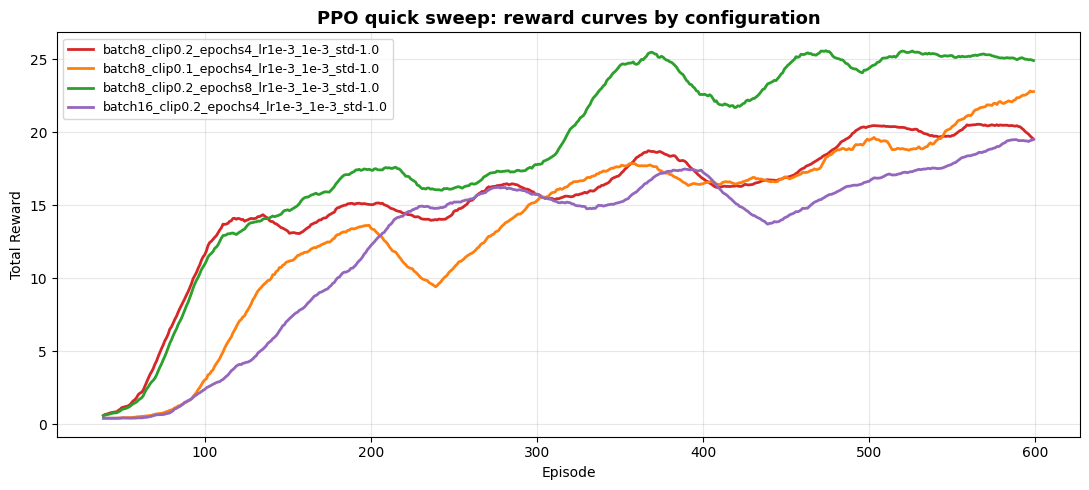

Final PPO config comparison across quick-sweep seeds (last 50 episodes):
batch8_clip0.2_epochs4_lr1e-3_1e-3_std-1.0    | reward:   20.1 +/-  0.0
batch8_clip0.1_epochs4_lr1e-3_1e-3_std-1.0    | reward:   22.7 +/-  0.0
batch8_clip0.2_epochs8_lr1e-3_1e-3_std-1.0    | reward:   24.9 +/-  0.0
batch16_clip0.2_epochs4_lr1e-3_1e-3_std-1.0   | reward:   19.5 +/-  0.0

Selected PPO config for downstream cells: batch8_clip0.2_epochs8_lr1e-3_1e-3_std-1.0
Using seed 0 as the representative PPO policy for rollout cells.


In [36]:
# ============================================================
# PPO benchmark on the shared crawler protocol
# ============================================================

PPO_TUNING_CONFIG = {
    'n_episodes': compare_episodes,
    'batch_episodes': 8,
    'clip_eps': 0.2,
    'train_epochs': 4,
    'minibatch_size': 500,
    'lr_actor': 1e-3,
    'lr_critic': 1e-3,
    'value_coef': 0.5,
    'max_grad_norm': 0.5,
    'init_log_std': -1.0,
}

PPO_SWEEP_PRESETS = [
    {
        'name': 'batch8_clip0.2_epochs4_lr1e-3_1e-3_std-1.0',
        **PPO_TUNING_CONFIG,
    },
    {
        'name': 'batch8_clip0.1_epochs4_lr1e-3_1e-3_std-1.0',
        **PPO_TUNING_CONFIG,
        'clip_eps': 0.1,
    },
    {
        'name': 'batch8_clip0.2_epochs8_lr1e-3_1e-3_std-1.0',
        **PPO_TUNING_CONFIG,
        'train_epochs': 8,
    },
    {
        'name': 'batch16_clip0.2_epochs4_lr1e-3_1e-3_std-1.0',
        **PPO_TUNING_CONFIG,
        'batch_episodes': 16
    },
]

print(f"=== L7-1: PPO on the same crawler ({len(range(1))} quick-sweep seeds) ===")
print('Actor: Gaussian policy')
print('Critic: learned value baseline V(s)')
print('Extra idea: clipped policy-ratio update for more stable policy improvement')
ppo_seeds = list(range(1))
ppo_sweep_results = {}
ppo_curve_colors = ['tab:red', 'tab:orange', 'tab:green', 'tab:purple', 'tab:brown', 'tab:pink']

for ppo_config in PPO_SWEEP_PRESETS:
    ppo_config = ppo_config.copy()
    ppo_episodes = ppo_config['n_episodes']
    print(f"\n=== PPO config: {ppo_config['name']} ===")
    config_results = {
        'config': ppo_config.copy(),
        'policies_by_seed': {},
        'critics_by_seed': {},
        'reward_histories_by_seed': {},
        'adv_std_histories_by_seed': {},
    }

    for seed in ppo_seeds:
        env_ppo = CrawlerEnv()
        ppo_meta = {
            'demo': 'L7-1',
            'variant': 'ppo',
            'seed': seed,
            'n_episodes': ppo_episodes,
            'batch_episodes': ppo_config['batch_episodes'],
            'clip_eps': ppo_config['clip_eps'],
            'train_epochs': ppo_config['train_epochs'],
            'lr_actor': ppo_config['lr_actor'],
            'lr_critic': ppo_config['lr_critic'],
            'init_log_std': ppo_config['init_log_std'],
            'config_name': ppo_config['name'],
        }
        ppo_checkpoint_label = f"L7-1: PPO [{ppo_config['name']}] (seed {seed})"
        latest = maybe_load_pg_checkpoint(
            kind='ppo',
            obs_dim=env_ppo.obs_dim,
            act_dim=env_ppo.act_dim,
            hidden=64,
            label=ppo_checkpoint_label,
            extra_meta=ppo_meta,
            with_critic=True,
        )
        if latest is None:
            print(f'  Seed {seed}: training')
            actor_seed, critic_seed, rewards_seed, adv_std_seed = train_ppo(
                env_ppo,
                n_episodes=ppo_episodes,
                batch_episodes=ppo_config['batch_episodes'],
                clip_eps=ppo_config['clip_eps'],
                train_epochs=ppo_config['train_epochs'],
                minibatch_size=ppo_config['minibatch_size'],
                lr_actor=ppo_config['lr_actor'],
                lr_critic=ppo_config['lr_critic'],
                value_coef=ppo_config['value_coef'],
                max_grad_norm=ppo_config['max_grad_norm'],
                init_log_std=ppo_config['init_log_std'],
                seed=seed,
                verbose=True,
                checkpoint_label=ppo_checkpoint_label,
                checkpoint_meta=ppo_meta,
            )
        else:
            print(f'  Seed {seed}: loaded')
            actor_seed, critic_seed, rewards_seed, extras = latest
            adv_std_seed = list(extras.get('adv_std_history', []))

        config_results['policies_by_seed'][seed] = actor_seed
        config_results['critics_by_seed'][seed] = critic_seed
        config_results['reward_histories_by_seed'][seed] = rewards_seed
        config_results['adv_std_histories_by_seed'][seed] = adv_std_seed

    ppo_sweep_results[ppo_config['name']] = config_results

fig, ax = plt.subplots(figsize=(11, 5))
for idx, (config_name, config_results) in enumerate(ppo_sweep_results.items()):
    plot_seed_average(
        ax,
        list(config_results['reward_histories_by_seed'].values()),
        color=ppo_curve_colors[idx % len(ppo_curve_colors)],
        label=config_name,
        window=40,
        alpha=0.12,
    )
ax.set_title('PPO quick sweep: reward curves by configuration', fontsize=13, fontweight='bold')
ax.set_xlabel('Episode')
ax.set_ylabel('Total Reward')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('Final PPO config comparison across quick-sweep seeds (last 50 episodes):')
for config_name, config_results in ppo_sweep_results.items():
    reward_mean, reward_std = summarize_final_window(
        list(config_results['reward_histories_by_seed'].values()),
        tail=50,
    )
    print(f'{config_name:45s} | reward: {reward_mean:6.1f} +/- {reward_std:4.1f}')

best_ppo_config_name = max(
    ppo_sweep_results,
    key=lambda name: summarize_final_window(
        list(ppo_sweep_results[name]['reward_histories_by_seed'].values()),
        tail=50,
    )[0],
)
ppo_results = ppo_sweep_results[best_ppo_config_name]
ppo_config = ppo_results['config'].copy()
print(f"\nSelected PPO config for downstream cells: {best_ppo_config_name}")

ppo_seed = max(
    ppo_results['reward_histories_by_seed'],
    key=lambda s: np.mean(ppo_results['reward_histories_by_seed'][s][-50:])
)
ppo_actor = ppo_results['policies_by_seed'][ppo_seed]
ppo_critic = ppo_results['critics_by_seed'][ppo_seed]
rewards_ppo = ppo_results['reward_histories_by_seed'][ppo_seed]
adv_std_ppo = ppo_results['adv_std_histories_by_seed'][ppo_seed]
print(f'Using seed {ppo_seed} as the representative PPO policy for rollout cells.')


## PPO Tuning Runner

Run this quick sweep immediately after the standalone PPO definition if you want to test the tuning knobs before doing the full lecture comparison.

Suggested workflow:
- Start with 3 to 4 seeds and compare all presets on the same plot.
- If one configuration is clearly better, promote only that winner to a wider confirmation run.
- Treat the selected PPO config below as the representative one for the later comparison cells.


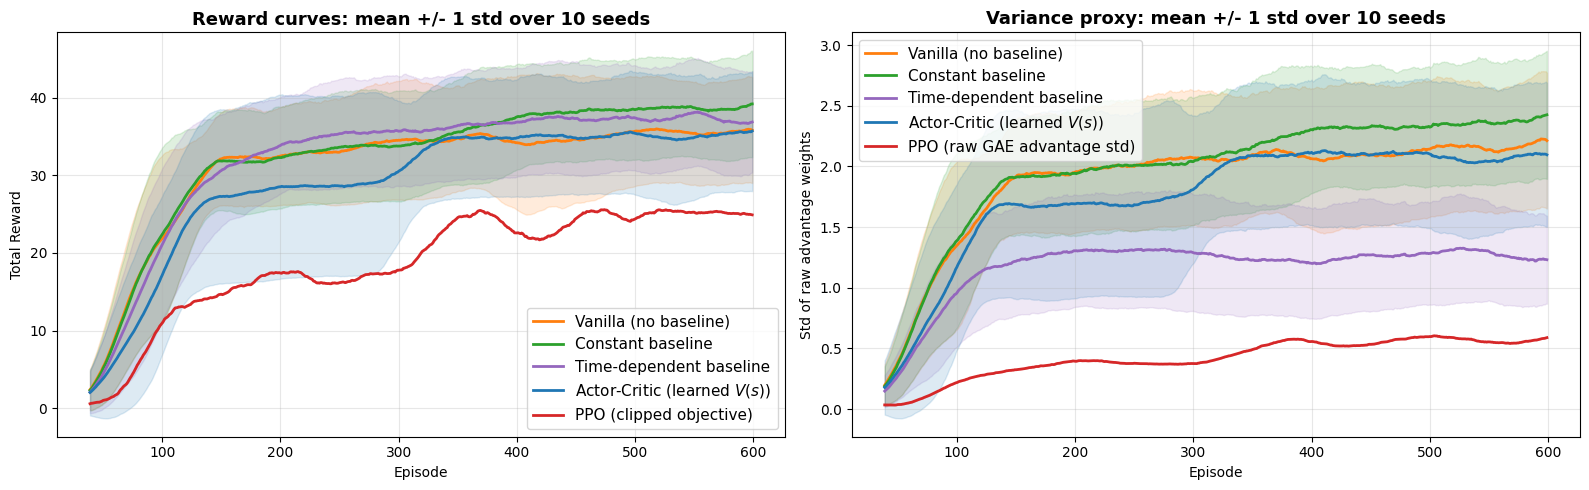

Final comparison across 10 seeds (last 50 episodes):
Vanilla (no baseline)    | reward:   35.7 +/-  6.7 | std:   2.19 +/- 0.55
Constant baseline        | reward:   38.9 +/-  6.6 | std:   2.40 +/- 0.51
Time-dependent baseline  | reward:   36.8 +/-  6.7 | std:   1.23 +/- 0.37
Actor-Critic (learned)   | reward:   35.6 +/-  7.5 | std:   2.09 +/- 0.58
PPO (clipped objective)  | reward:   24.9 +/-  0.0 | std:   0.57 +/- 0.00


In [41]:
# PPO vs previous baselines on the same crawler protocol
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
window = 40

ax = axes[0]
for label, result in baseline_results.items():
    plot_seed_average(
        ax,
        list(result['reward_histories_by_seed'].values()),
        color=result['color'],
        label=label,
        window=window,
    )
plot_seed_average(
    ax,
    list(actor_critic_results['reward_histories_by_seed'].values()),
    color='tab:blue',
    label='Actor-Critic (learned $V(s)$)',
    window=window,
)
plot_seed_average(
    ax,
    list(ppo_results['reward_histories_by_seed'].values()),
    color='tab:red',
    label='PPO (clipped objective)',
    window=window,
)
ax.set_title('Reward curves: mean +/- 1 std over 10 seeds', fontsize=13, fontweight='bold')
ax.set_xlabel('Episode')
ax.set_ylabel('Total Reward')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

ax = axes[1]
for label, result in baseline_results.items():
    plot_seed_average(
        ax,
        list(result['adv_std_histories_by_seed'].values()),
        color=result['color'],
        label=label,
        window=window,
    )
plot_seed_average(
    ax,
    list(actor_critic_results['adv_std_histories_by_seed'].values()),
    color='tab:blue',
    label='Actor-Critic (learned $V(s)$)',
    window=window,
)
plot_seed_average(
    ax,
    list(ppo_results['adv_std_histories_by_seed'].values()),
    color='tab:red',
    label='PPO (raw GAE advantage std)',
    window=window,
)
ax.set_xlabel('Episode')
ax.set_ylabel('Std of raw advantage weights')
ax.set_title('Variance proxy: mean +/- 1 std over 10 seeds', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Final comparison across 10 seeds (last 50 episodes):')
for label, result in baseline_results.items():
    reward_mean, reward_std = summarize_final_window(list(result['reward_histories_by_seed'].values()), tail=50)
    var_mean, var_std = summarize_final_window(list(result['adv_std_histories_by_seed'].values()), tail=50)
    print(f'{label:24s} | reward: {reward_mean:6.1f} +/- {reward_std:4.1f} | std: {var_mean:6.2f} +/- {var_std:4.2f}')

ac_reward_mean, ac_reward_std = summarize_final_window(list(actor_critic_results['reward_histories_by_seed'].values()), tail=50)
ac_var_mean, ac_var_std = summarize_final_window(list(actor_critic_results['adv_std_histories_by_seed'].values()), tail=50)
print(f"{'Actor-Critic (learned)':24s} | reward: {ac_reward_mean:6.1f} +/- {ac_reward_std:4.1f} | std: {ac_var_mean:6.2f} +/- {ac_var_std:4.2f}")

ppo_reward_mean, ppo_reward_std = summarize_final_window(list(ppo_results['reward_histories_by_seed'].values()), tail=50)
ppo_var_mean, ppo_var_std = summarize_final_window(list(ppo_results['adv_std_histories_by_seed'].values()), tail=50)
print(f"{'PPO (clipped objective)':24s} | reward: {ppo_reward_mean:6.1f} +/- {ppo_reward_std:4.1f} | std: {ppo_var_mean:6.2f} +/- {ppo_var_std:4.2f}")


In [24]:
# 10-second rollout of the representative PPO policy
env_eval_ppo = CrawlerEnv()

def ppo_policy(obs):
    with torch.no_grad():
        obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
        mu, _ = ppo_actor(obs_t)
        return mu.squeeze(0).cpu().numpy()

frames_ppo, dist_ppo, _ = eval_policy(env_eval_ppo, ppo_policy, 'L7-1: PPO')
show_video(frames_ppo, title=f'PPO — {dist_ppo:.2f}m in 10s')


L7-1: PPO: traveled 0.48m in 10s  (episode reward: 24.0)


In [ ]:
# Final comparison: representative policies from the policy-gradient family
policy_panels = []
comparison_results = {}

def add_policy_panel(label, policy_fn, *, env=None, video_title=None, max_steps=500,
                     frames=None, dist=None):
    if frames is None or dist is None:
        if env is None:
            env = CrawlerEnv(max_steps=max_steps)
        frames, dist, _ = eval_policy(env, policy_fn, label, max_steps=max_steps)
    comparison_results[label] = dist
    video_html = show_video(frames, title=video_title or f'{label} — {dist:.2f}m in 10s').data
    policy_panels.append({
        'label': label,
        'distance': dist,
        'video_html': video_html,
    })

def representative_seed(history_dict):
    return max(history_dict, key=lambda s: np.mean(history_dict[s][-50:]))

def make_comparison_plot_base64(results_dict, title='Policy Comparison: Distance Traveled in 10s'):
    labels = list(results_dict.keys())
    dists = list(results_dict.values())
    colors = ['#d9534f' if d < 0.5 else '#5bc0de' if d < 1.5 else '#5cb85c' for d in dists]
    fig, ax = plt.subplots(figsize=(9, max(4, len(labels) * 0.55 + 1.2)))
    bars = ax.barh(labels, dists, color=colors, edgecolor='white', height=0.6)
    ax.set_xlabel('Distance (m)')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axvline(x=0, color='gray', linewidth=0.5)
    for bar, d in zip(bars, dists):
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                f'{d:.2f}m', va='center', fontsize=11)
    ax.invert_yaxis()
    plt.tight_layout()
    buf = BytesIO()
    fig.savefig(buf, format='png', dpi=160, bbox_inches='tight')
    plt.close(fig)
    return base64.b64encode(buf.getvalue()).decode('ascii')

reinforce_meta = {
    'demo': '5',
    'variant': 'reinforce',
    'n_episodes': 4500,
}
env_tmp = CrawlerEnv()
loaded = maybe_load_pg_checkpoint(
    kind='reinforce',
    obs_dim=env_tmp.obs_dim,
    act_dim=env_tmp.act_dim,
    hidden=64,
    label='Demo 5: REINFORCE',
    extra_meta=reinforce_meta,
)
if loaded is None:
    raise RuntimeError('Expected the Demo 5 REINFORCE checkpoint to exist, but none was found.')
policy_reinforce, rewards_reinforce, reinforce_extras = loaded

def reinforce_policy(obs):
    with torch.no_grad():
        obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
        mu, _ = policy_reinforce(obs_t)
        return mu.squeeze(0).cpu().numpy()

const_seed = representative_seed(baseline_results['Constant baseline']['reward_histories_by_seed'])
const_policy_model = baseline_results['Constant baseline']['policies_by_seed'][const_seed]
def constant_baseline_policy(obs):
    with torch.no_grad():
        obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
        mu, _ = const_policy_model(obs_t)
        return mu.squeeze(0).cpu().numpy()

time_seed = representative_seed(baseline_results['Time-dependent baseline']['reward_histories_by_seed'])
time_policy_model = baseline_results['Time-dependent baseline']['policies_by_seed'][time_seed]
def time_baseline_policy(obs):
    with torch.no_grad():
        obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
        mu, _ = time_policy_model(obs_t)
        return mu.squeeze(0).cpu().numpy()

def actor_critic_policy(obs):
    with torch.no_grad():
        obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
        mu, _ = actor_ac(obs_t)
        return mu.squeeze(0).cpu().numpy()

if 'frames_ppo' in globals() and 'dist_ppo' in globals():
    add_policy_panel('L7-1: PPO', ppo_policy, video_title='PPO', frames=frames_ppo, dist=dist_ppo)
else:
    add_policy_panel('L7-1: PPO', ppo_policy, video_title='PPO')
add_policy_panel('Demo 5: REINFORCE', reinforce_policy, video_title='REINFORCE')
add_policy_panel('Demo 6: Constant baseline', constant_baseline_policy, video_title='Constant baseline')
add_policy_panel('Demo 6: Time baseline', time_baseline_policy, video_title='Time-dependent baseline')
add_policy_panel('Demo 7: Actor-Critic', actor_critic_policy, video_title='Actor-Critic')

plot_png = make_comparison_plot_base64(comparison_results)
cards_html = ''.join(
    f"<div style='background:#fff;border:1px solid #ddd;border-radius:10px;padding:10px;'>"
    f"<div style='font-weight:600;margin-bottom:8px'>{panel['label']} ({panel['distance']:.2f}m)</div>"
    f"{panel['video_html']}"
    f"</div>"
    for panel in policy_panels
)
display(HTML(
    f"""
<div style='display:grid;grid-template-columns:minmax(340px, 420px) 1fr;gap:20px;align-items:start;'>
  <div style='background:#fff;border:1px solid #ddd;border-radius:10px;padding:12px;'>
    <div style='font-weight:700;font-size:18px;margin-bottom:10px;'>Distance traveled in 10 seconds</div>
    <img src='data:image/png;base64,{plot_png}' style='width:100%;height:auto;display:block;' />
  </div>
  <div style='display:flex;flex-direction:column;gap:16px;'>
    {cards_html}
  </div>
</div>
"""
))


## Reading the result

The quantity on the right is not a formal variance proof. It is a practical proxy: the standard deviation of the **raw advantage weights** used before normalization.

What the current saved output actually shows:
- The current PPO tuning sweep is only a **1-seed quick sweep**, so the PPO config ranking itself is still provisional.
- Within that saved sweep, the best PPO preset is `batch8_clip0.2_epochs8_lr1e-3_1e-3_std-1.0`, reaching about **24.9** average reward over the last 50 episodes and about **0.48 m** in the 10-second rollout.
- On this crawler task, PPO is **not** the top performer in raw reward: the saved comparison reports about **35.1** for the time-dependent baseline, **33.3** for the constant baseline, **31.5** for Actor-Critic, **29.7** for vanilla REINFORCE, and **24.9** for PPO.
- PPO's strongest evidence here is the variance proxy: its raw advantage std is about **0.57**, versus **1.28** for the time-dependent baseline and roughly **1.78 to 2.01** for the other policy-gradient baselines. So on the crawler, PPO currently looks more like a **variance-control method** than a raw-performance win.

Additional learning objective: scaling beyond the crawler
- The crawler is still a small 2D task with only 2 continuous actions. That is useful for understanding the algorithm, but it is not yet the setting where PPO should be expected to show its biggest practical advantage.
- A better next comparison is a harder continuous-control environment such as a **Humanoid 3D** task, where the action space is much larger, trajectories are longer, and credit assignment is harder.
- The notebook should therefore add three follow-on demos: `REINFORCE` on Humanoid 3D, `REINFORCE with baseline / Actor-Critic` on Humanoid 3D, and `PPO` on Humanoid 3D, all evaluated with the same rollout metric and aligned training-curve plots.
- The intended lesson is that as the task becomes more complex, REINFORCE-style methods tend to **flatten** or become too noisy, while PPO's clipped updates can keep learning moving and scale more gracefully.
- In other words, the crawler notebook motivates the mechanism, and the humanoid demo should supply the stronger scaling evidence.